from google.colab import drive
drive.mount('/content/drive')

!rm -r /content/Brain_MRI

!unzip /content/drive/MyDrive/Brain_MRI.zip -d Brain_MRI

!pip install onnxruntime-gpu rembg[gpu] --force-reinstall

!pip install protobuf==3.20.*

# Problem Statement: Build a AI solution to detect brain tumor with explainability (XAI).

## Data Soruce: 
- We have used brain tumor segmentation dataset

## Solution Overview
- A hybrid CNN–Attention U-Net architecture with residual ConvBlocks, Multi-Head Self-Attention (MHSA), and Squeeze-and-Excitation (SE) modules.
- The encoder captures local and global context, while the attention-enhanced decoder refines spatial details using skip connections.
- Joint learning is performed for segmentation (Dice + BCE loss) and classification (softmax), improving feature robustness.
- Evaluation uses Dice coefficient and IoU to handle class imbalance and assess segmentation quality.

In [1]:
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import glob, os
import seaborn as sb
import pandas as pd
import tensorflow as tf
import cv2, json
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import ModelCheckpoint
from SabreNet import build_model, dice_loss_plus_bce, iou_metric, dice_coefficient, SEFMetric
from utils import plot_history, data_gen
!nvidia-smi -L

C:\Users\Lucifer\AppData\Roaming\Python\Python310\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.2.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


GPU 0: NVIDIA GeForce RTX 3060 (UUID: GPU-81f6e2eb-490f-a94c-111c-389f658c4c02)


In [2]:
files = glob.glob('dataset/Segmentation/*/*')

In [3]:
lab = {'glioma' : 0, 'meningioma' : 1, 'pituitary' : 2}
rev_lab = dict(zip(lab.values(), lab.keys()))

In [4]:
image_path = [files[i] for i in range(0, len(files), 2)]
mask_path = [files[i] for i in range(1, len(files), 2)]

df = pd.DataFrame.from_dict({"image_path" : image_path, "mask_path" : mask_path})

df["label"] = df["image_path"].str.lower().str.split("\\").str[1]

df['label'] = df['label'].apply(lab.get)

df

,image_path,mask_path,label
0,dataset/Segmentation\Glioma\enh_1841.png,dataset/Segmentation\Glioma\enh_1841_mask.png,0
1,dataset/Segmentation\Glioma\enh_1842.png,dataset/Segmentation\Glioma\enh_1842_mask.png,0
2,dataset/Segmentation\Glioma\enh_1843.png,dataset/Segmentation\Glioma\enh_1843_mask.png,0
3,dataset/Segmentation\Glioma\enh_1844.png,dataset/Segmentation\Glioma\enh_1844_mask.png,0
4,dataset/Segmentation\Glioma\enh_1845.png,dataset/Segmentation\Glioma\enh_1845_mask.png,0
...,...,...,...
2187,dataset/Segmentation\Pituitary\enh_995.png,dataset/Segmentation\Pituitary\enh_995_mask.png,2
2188,dataset/Segmentation\Pituitary\enh_996.png,dataset/Segmentation\Pituitary\enh_996_mask.png,2
2189,dataset/Segmentation\Pituitary\enh_997.png,dataset/Segmentation\Pituitary\enh_997_mask.png,2
2190,dataset/Segmentation\Pituitary\enh_998.png,dataset/Segmentation\Pituitary\enh_998_mask.png,2


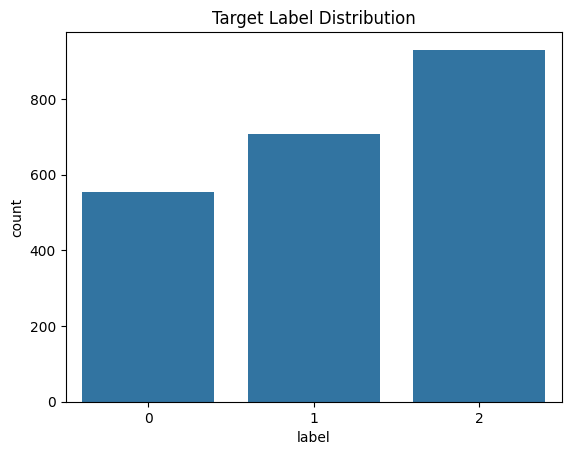

In [5]:
plt.title('Target Label Distribution')
sb.countplot(x = df['label'])
plt.show()

In [6]:
train_df, val_df  = train_test_split(df, test_size=0.20, random_state=100, stratify=df['label'])

In [7]:
len(train_df), len(val_df)

(1753, 439)

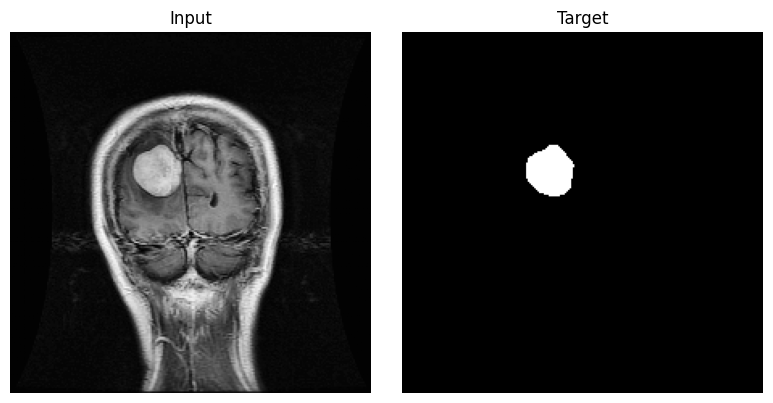

In [8]:
sampx, sampy = next(data_gen(val_df, 3))
sampy1, sampy2 = sampy

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].axis('off')
axes[0].imshow(sampx[1, ...], cmap='gray')
axes[0].set_title("Input")

axes[1].axis('off')
axes[1].imshow(sampy1[1, ...], cmap='gray')
axes[1].set_title("Target")

plt.tight_layout()
plt.show()

In [9]:
sampx.shape, sampy1.shape, sampy2.shape

((3, 224, 224, 1), (3, 224, 224, 1), (3, 3))

In [10]:
sampx.max(), sampy1.max()

(1.0, 1.0)

# CNN + Multi-Head Self-Attention

In [12]:
model = build_model(input_shape=(224,224,1), num_classes=3)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = .0001),
    loss={'mask_pred': dice_loss_plus_bce,#bce_dice_loss,
          'classifier': 'categorical_crossentropy'
         },
    metrics={'mask_pred': [dice_coefficient, iou_metric, SEFMetric()],
             'classifier': ['accuracy']}
)

model.summary()

Model: "SabreNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input (InputLayer)             [(None, 224, 224, 1  0           []                               
                                )]                                                                
                                                                                                  
 stem_conv (Conv2D)             (None, 112, 112, 64  3136        ['input[0][0]']                  
                                )                                                                 
                                                                                                  
 stem_bn (BatchNormalization)   (None, 112, 112, 64  256         ['stem_conv[0][0]']              
                                )                                                          

In [13]:
tf.keras.utils.plot_model(model)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [14]:
batch_size = 4
train = data_gen(train_df, batch_size)
val = data_gen(train_df, batch_size)

In [15]:
calls = [
    ModelCheckpoint('BT_CLF_Attention.h5', monitor='mask_pred_loss', save_best_only=True, verbose=True, save_weights_only=True)
]

In [16]:
len(train_df)//batch_size, len(val_df)//batch_size

(438, 109)

In [ ]:
history = model.fit(train, epochs = 1000, steps_per_epoch = 250, validation_data=val, validation_steps=50, callbacks = calls)

Epoch 1/1000
250/250 [==============================] - ETA: 0s - loss: 2.0610 - mask_pred_loss: 1.1177 - classifier_loss: 0.9433 - mask_pred_dice_coefficient: 0.0819 - mask_pred_iou_metric: 0.0437 - mask_pred_sef: 0.1627 - classifier_accuracy: 0.5300
Epoch 1: mask_pred_loss improved from inf to 1.11773, saving model to BT_CLF_Attention.h5
250/250 [==============================] - 53s 175ms/step - loss: 2.0610 - mask_pred_loss: 1.1177 - classifier_loss: 0.9433 - mask_pred_dice_coefficient: 0.0819 - mask_pred_iou_metric: 0.0437 - mask_pred_sef: 0.1627 - classifier_accuracy: 0.5300 - val_loss: 2.2063 - val_mask_pred_loss: 1.1169 - val_classifier_loss: 1.0894 - val_mask_pred_dice_coefficient: 0.0728 - val_mask_pred_iou_metric: 0.0384 - val_mask_pred_sef: 0.1731 - val_classifier_accuracy: 0.3550
Epoch 2/1000
117/250 [=============>................] - ETA: 20s - loss: 1.8741 - mask_pred_loss: 1.0297 - classifier_loss: 0.8445 - mask_pred_dice_coefficient: 0.1207 - mask_pred_iou_metric: 0.06

In [ ]:
# with open("training_history_attention.json", "w") as f:
#     json.dump(hiistory.history, f)

In [2]:
with open("training_history_attention.json", "r") as f:
    history = json.load(f)

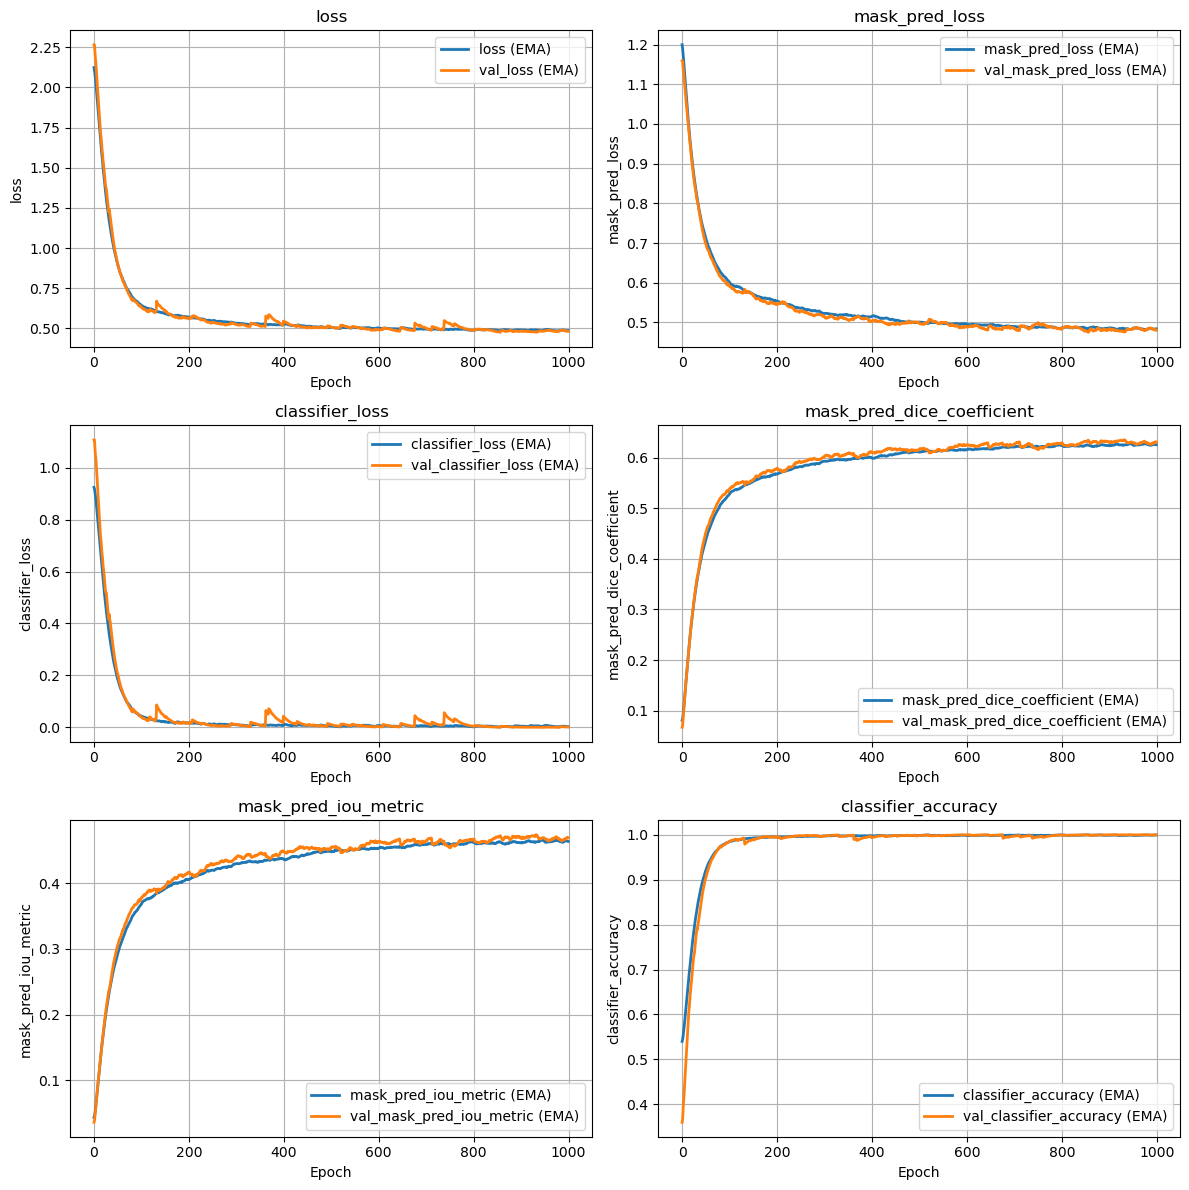

In [4]:
plot_history(history)

In [14]:
model.load_weights('BT_CLF_Attention.h5')

In [168]:
sampx, sampy1 = next(data_gen(val_df, 3))
sampy1, sampy2 = sampy1

In [ ]:
def make_random_donut(
    shape=(224, 224, 1),
    outer_radius_range=(35, 60),
    inner_radius_range=(12, 28),
    center_jitter=50,
    value=1.0,
    background=0.0,
    dtype=np.float32,):
    """
    Create a random donut mask with shape (H, W, 1).

    Parameters
    ----------
    shape : tuple
        Output shape, expected as (H, W, 1).
    outer_radius_range : tuple
        Min and max outer radius.
    inner_radius_range : tuple
        Min and max inner radius.
    center_jitter : int
        Max random shift from image center in pixels.
    value : float
        Pixel value for the donut.
    background : float
        Pixel value for the background.
    dtype : numpy dtype
        Output dtype.

    Returns
    -------
    img : np.ndarray
        Donut image of shape (224, 224, 1).
    """

    H, W, C = shape
    assert C == 1, "Shape must be (H, W, 1)"

    img = np.full((H, W), background, dtype=dtype)

    # Random radii
    outer_r = np.random.randint(*outer_radius_range)
    inner_r = np.random.randint(*inner_radius_range)

    # Make sure inner radius is smaller than outer radius
    inner_r = min(inner_r, outer_r - 5)

    # Random center around the image center
    cx = W // 2 + np.random.randint(-center_jitter, center_jitter + 1)
    cy = H // 2 + np.random.randint(-center_jitter, center_jitter + 1)

    # Optional safety clamp so the donut mostly stays inside the image
    margin = outer_r + 1
    cx = np.clip(cx, margin, W - margin - 1)
    cy = np.clip(cy, margin, H - margin - 1)

    y, x = np.ogrid[:H, :W]
    dist_sq = (x - cx) ** 2 + (y - cy) ** 2

    donut = (dist_sq <= outer_r ** 2) & (dist_sq >= inner_r ** 2)

    img[donut] = value

    return img[..., None]

GT:  pituitary
Pred: meningioma (0.9532793164253235)


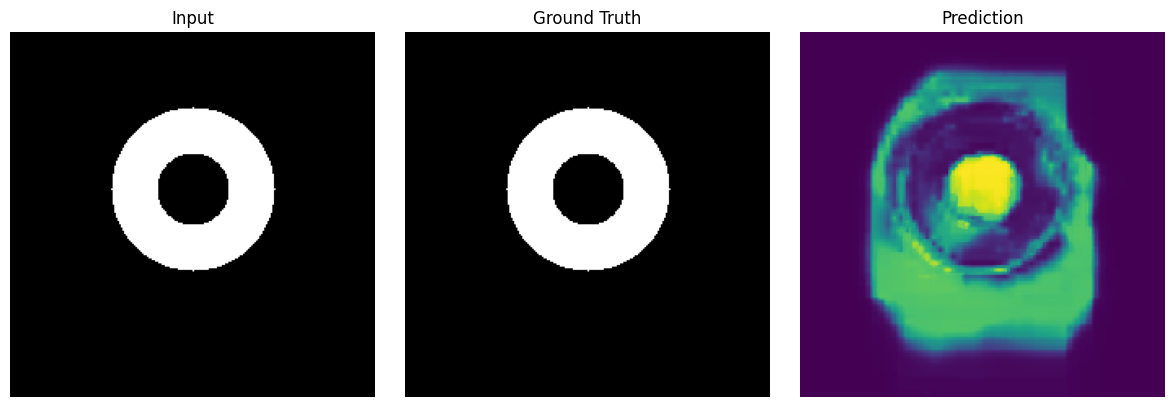

In [198]:
idx = 2

img = sampx[idx]

img = make_random_donut()

gt_cls = rev_lab.get(np.argmax(sampy2[idx]))
gt_mask = img #sampy1[idx]

print("GT: ", gt_cls)

res = model.predict(np.expand_dims(img, 0), verbose=False)
print(f"Pred: {rev_lab.get(np.argmax(res[1]))} ({np.max(res[1])})")

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Input")
axes[0].axis("off")

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(res[0][0])
axes[2].set_title("Prediction")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [199]:
res[0].shape, res[1].shape

((1, 224, 224, 1), (1, 3))

In [200]:
len(res)

2

In [201]:
from grad_cam import plot_gradcam

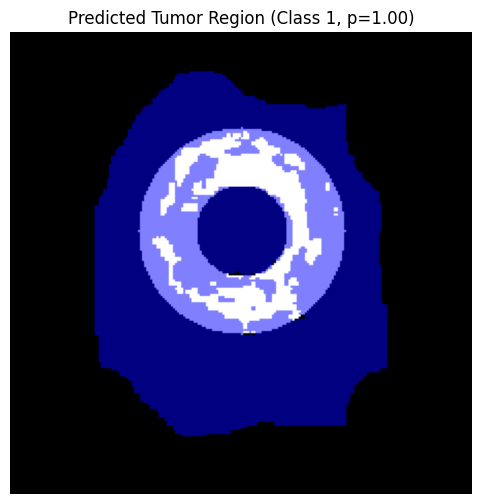

✅ Saved Predicted Mask Overlay
🔍 Computing Seg-Grad-CAM for layer: block1
🔍 Computing Seg-Grad-CAM for layer: block2
🔍 Computing Seg-Grad-CAM for layer: b2_mhsa_reshape_back
🔍 Computing Seg-Grad-CAM for layer: block3
🔍 Computing Seg-Grad-CAM for layer: b3_mhsa_reshape_back
🔍 Computing Seg-Grad-CAM for layer: block4
🔍 Computing Seg-Grad-CAM for layer: b4_mhsa_reshape_back
🔍 Computing Seg-Grad-CAM for layer: up_block1
🔍 Computing Seg-Grad-CAM for layer: up1_mhsa_reshape_back
🔍 Computing Seg-Grad-CAM for layer: se_block
🔍 Computing Seg-Grad-CAM for layer: up_block2
🔍 Computing Seg-Grad-CAM for layer: up2_mhsa_reshape_back
🔍 Computing Seg-Grad-CAM for layer: se_block_1
🔍 Computing Seg-Grad-CAM for layer: up_block3
🔍 Computing Seg-Grad-CAM for layer: up3_mhsa_reshape_back
🔍 Computing Seg-Grad-CAM for layer: se_block_2
🔍 Computing Seg-Grad-CAM for layer: up4_mhsa_reshape_back
🔍 Computing Seg-Grad-CAM for layer: mask_pred


In [202]:
im = img*255
im = im.astype(np.uint8)
im = cv2.cvtColor(im, cv2.COLOR_GRAY2BGR)
grads = plot_gradcam(im, model, False)

In [231]:
grad = grads[-1]
grad = make_random_donut()
grad = grad/grad.max()
grad = grad>0.5
grad = grad.astype(np.float32)

gt = img>0.5
gt = gt.astype(np.float32)
gt = np.squeeze(gt)

In [232]:
grad.max(), grad.min(), gt.max(), gt.min()

(1.0, 0.0, 1.0, 0.0)

In [233]:
grad.shape, gt.shape

((224, 224, 1), (224, 224))

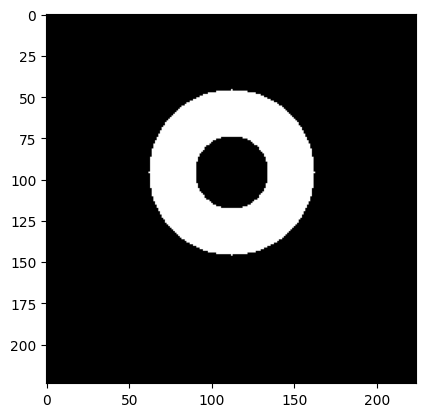

In [234]:
plt.imshow(gt, cmap='gray')

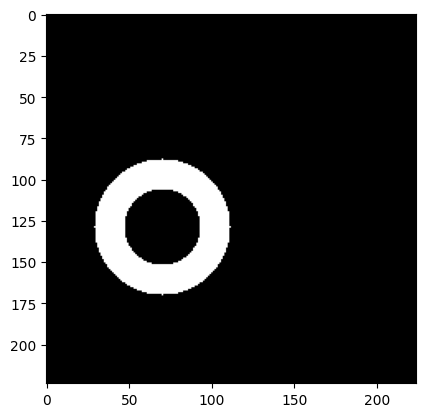

In [235]:
plt.imshow(grad, cmap='gray')

In [ ]:
from scipy.ndimage import distance_transform_edt

In [ ]:
epsilon = np.finfo(np.float32).eps
intersection = np.logical_and(grad == 1, gt == 1).sum()
union = np.logical_or(grad == 1, gt == 1).sum()
IoU = intersection / (union + epsilon)

intersection = np.logical_and(grad == 1, gt == 1).sum()
gt_area = (gt == 1).sum()
Coverage = intersection / (gt_area + epsilon)

dist_map = distance_transform_edt(1 - gt)

D = np.sum(grad * dist_map**2) / (np.sum(grad) + epsilon)

ys, xs = np.where(gt == 1)

w_gt = xs.max() - xs.min() + 1
h_gt = ys.max() - ys.min() + 1

s_gt = np.sqrt(w_gt**2 + h_gt**2)

D_norm = D / (s_gt**2 + epsilon)
Focus = 1 / (1 + D_norm)

FinalScore = IoU * Coverage * Focus